In [1]:
import glob
import numpy as np
from numpy.testing import assert_array_equal, assert_allclose
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import darshan
from darshan.experimental.plots import heatmap_handling, plot_dxt_heatmap
from darshan.log_utils import get_log_path
darshan.enable_experimental(verbose=True)

Added method darshan.experimental.aggregators.mod_agg_iohist to DarshanReport.
Added method darshan.experimental.aggregators.create_time_summary to DarshanReport.
Added method darshan.experimental.aggregators.print_module_records to DarshanReport.
Added method darshan.experimental.aggregators.create_timeline to DarshanReport.
Added method darshan.experimental.aggregators.summarize to DarshanReport.
Added method darshan.experimental.aggregators.create_dxttimeline to DarshanReport.
Added method darshan.experimental.aggregators.agg_ioops to DarshanReport.
Added method darshan.experimental.aggregators.name_records_summary to DarshanReport.
Added method darshan.experimental.aggregators.records_as_dict to DarshanReport.
Added method darshan.experimental.aggregators.create_sankey to DarshanReport.
Added method darshan.experimental.operations.filter to DarshanReport.
Added method darshan.experimental.operations.reduce to DarshanReport.
Added method darshan.experimental.operations.merge to Dars

In [41]:
from darshan.report import *


def configure_groups():
    """
    Prepare a dictionary to lookup high level group ordering.
    """
    from collections import OrderedDict 

    order = 0.0
    group_config = OrderedDict()

    group_config['H5F'] = {}
    group_config['H5D'] = {}
    group_config['MPIIO'] = {}
    group_config['DXT_MPIIO'] = {}
    group_config['STDIO'] = {}
    group_config['POSIX'] = {}
    group_config['DXT_POSIX'] = {}
    group_config['LUSTRE'] = {}
    group_config['HEATMAP'] = {}

    # apply order
    for k,v in group_config.items():
        v['order'] = order
        order += 1.0

    return group_config

def purge_empty_nestedGroups(groups):
    for k,v in groups.items():
        if 'nestedGroups' in v:
            if len(v['nestedGroups']) == 0:
                v.pop('nestedGroups', None)
                v.pop('showNested', None)

def normalize_mod(mod, inverse=False):
    mapping = {
        'MPI-IO': 'MPIIO'
    }

    inverse_mapping = {
        'MPIIO': 'MPI-IO'
    }

    if inverse and mod in inverse_mapping:
        return inverse_mapping[mod]

    if mod in mapping:
        return mapping[mod]

    return mod


def update_parent_item(self, groups, items, parent_id, start=None, end=None):
    item = None
    if parent_id in items:
        item = items[parent_id]
    else:
        items[parent_id] = {
            'id': parent_id,
            'group': parent_id,
            'content': '',
            'start': start,
            'end': end
        }
        item = items[parent_id]

    if start < item['start']:
        item['start'] = start
    if end > item['end']:
        item['end'] = end


def summarized_items(self, groups, items, mod, nmod, rec, rec_id, group_id, parent_group):
    if mod in ['LUSTRE']:
        # skip, nothing to summarize
        return
    
    item_id = f'{group_id}'
    start = float('inf')
    end = float('-inf')

    
    drec = {}
    drec['fcounters'] = dict(zip(self.counters[mod]['fcounters'], rec['fcounters']))


    # find min/max for starttime and endtime
    ops = ['OPEN', 'CLOSE']
    if mod not in ['H5F']:
        # add the following ops for all but H5F, ...
        ops += ['READ', 'WRITE']
    print(ops)
    for op in ops:
        item_id = f'{group_id}:{op}'
        print(item_id)
        cur_start = drec['fcounters'][f'{nmod}_F_{op}_START_TIMESTAMP']
        cur_end = drec['fcounters'][f'{nmod}_F_{op}_END_TIMESTAMP']
              
        if cur_start < start:
            start = cur_start      
        if cur_end > end:
            end = cur_end
    
        # add item
        if item_id not in items:
            items[item_id] = {
                'id': item_id,
                'group': group_id,
                'content': '',
                'start': start,
                'end': end
            }

    # order by first access
    if start < groups[group_id]['order']:
        groups[group_id]['order'] = start 
        
    update_parent_item(self, groups, items, parent_group, start=start, end=end)


def compress_pathname(pathname):
    max_len = 42
    
    if len(pathname) < max_len:
        return pathname
    
    elems = pathname.split('/')
    
    #if len(elems[-1]) < max_len:
    #    return elems[-1]
    
    snip = '...'
    
    return pathname[0:int((max_len-len(snip))/2)]  + snip + elems[-1][-int((max_len-len(snip))/2):]




def create_timeline(self, 
        group_by='mod,file,rank', 
        action='attach,overwrite', summary_name='timeline'
        ):
    """
    Generate/update a timeline from records of the current report state.

    Args:
        group_by (str): By which factor to group entries (default: rank)
                        Allowed Parameters: rank, filename
    """

    report = self

    groups = {}
    items = {}
    

    group_config = configure_groups()
    #start_time = datetime.datetime.fromtimestamp( self.data['metadata']['job']['start_time'] )



    for mod in report.modules:
        nmod = normalize_mod(mod)
        group_id = nmod
        
        groups[group_id] = {
            'id': group_id, 
            'content': f'{group_id}',
            'order': group_config[nmod]['order'],
            'nestedGroups': [], # to be filled later
            'showNested': False
        }

    
    for mod in report.modules:
        if mod in ['DXT_POSIX', 'DXT_MPIIO','HEATMAP','STDIO']:
            continue
        
        nmod = normalize_mod(mod)
        parent_group = nmod
        
        for rec in report.records[mod]:
            rec_id = rec['id']
            group_id = f'{nmod}:{rec_id}' 
            
            # add group
            if group_id not in groups:           
                groups[group_id] = {
                    'id': group_id, 
                    'content':
                        '<b>' +
                        compress_pathname(report.name_records[rec['id']]) +
                        '</b><br>' + 
                        f'{group_id}' + 
                        '',
                    'order': float('inf'),
                    'title': report.name_records[rec['id']],
                    'nestedGroups': [], # to be filled later
                    'showNested': False
                }
                groups[parent_group]['nestedGroups'].append(group_id)
            
            # add items
            #detailed_items(groups, items, mod, nmod, rec, rec_id, group_id, parent_group)
            summarized_items(self, groups, items, mod, nmod, rec, rec_id, group_id, parent_group)


    purge_empty_nestedGroups(groups)

    # flatten dictionaries to list
    timeline = {
        'groups': [v for k,v in groups.items()],
        'items': [v for k,v in items.items()]
    }

    # overwrite existing summary entry
    if action == "attach,overwrite":
        self.summary[summary_name] = timeline

    return timeline

In [22]:
def filter_record(r,ex_list=[],in_list=[]):
    nr=r.name_records
    # import fname,re
    names=list(nr.values())
    for k, v in nr.items():
        inclu=True
        if in_list!=[]:
            inclu=False
            for i in in_list:
                if i in v:
                    inclu=True
                    break
        if ex_list!=[]:
            for ex in ex_list:
                if ex in v:
                    inclu=False
        if not inclu:
            names.remove(v)
#     print(names)
#     print(set([x.split('/')[-1] for x in names]))
#     print('before',r.agg_ioops()['POSIX_simple']['Read'],r.agg_ioops()['POSIX_simple']['Write'])
    return r.reduce(name_records=names)
#     print('after',r.agg_ioops()['POSIX_simple']['Read'],r.agg_ioops()['POSIX_simple']['Write'])

In [27]:
ex_list=['.py','perfmon','.pmon.','PoolFileCatalog','eventLoopHeartBeat','.db','.so','atlas-condb','.conditions.','.txt'
         ,'.tmp','.log','Log','STD','POSIX']
in_list=['.pool.root']
files_ttbar=glob.glob('workdir/Athena_23_0_5/ttbar/athenaM*/rwang*.darshan')
reports_ttbar=[darshan.DarshanReport(file, read_all=True, dtype='numpy') for file in files_ttbar]
freports_ttbar=[filter_record(r,ex_list,in_list) for r in reports_ttbar]
reports_ttbar[4].info()

Filename:       workdir/Athena_23_0_5/ttbar/athenaMP_FullG4_ttbar_8_1_False/rwang_python_id63943-64283_10-6-16351-11103754300510929875_1.darshan
Times:          2022-10-06 04:32:31 to 2022-10-06 04:36:08 (Duration 0:03:37)
Executable:    /cvmfs/atlas-nightlies.cern.ch/repo/sw/master_Athena_x86_64-centos7-gcc11-opt/sw/lcg/releases/LCG_101_ATLAS_26/Python/3.9.6/x86_64-centos7-gcc11-opt/bin/python -tt /cvmfs/atlas-nightlies.cern.ch/repo/sw/master_Athena_x86_64-centos7-gcc11-opt/2022-10-04T2101/Athena/23.0.7/InstallArea/x86_64-centos7-gcc11-opt/bin/athena.py --stdcmalloc --preloadlib=/lcrc/group/ATLAS/users/rwang/Argonne_computing/PPS-CCE/darshan/build_darshan/dev-fork-child-issue786/lib/libdarshan.so --nprocs=8 runargs.EVNTtoHITS.py SimuJobTransforms/skeleton.EVGENtoHIT_ISF.py 
Processes:      1
JobID:          63943
UID:            8391
Modules in Log: ['POSIX', 'STDIO', 'DXT_POSIX', 'HEATMAP']
Loaded Records: {'POSIX': 21, 'STDIO': 7, 'DXT_POSIX': 17}
Name Records:   26
Darshan/Hints:  

In [168]:
df_ttbar=pd.DataFrame(columns=['athena','proc','evt','fork','time'
                               ,'posix read','posix write','posix open','posix stat','posix seek','posix mmap','posix fsync'
                              ,'posix bytes read','posix bytes written','posix max bytes read','posix max bytes written'])

for r in freports_ttbar:
    r=filter_record(r,ex_list,in_list)
#     print(r.name_records)
#     print('shared_writer' in r.name_records)
    file=r.filename.split('/')[3].split('_')
    athena=file[0]
    if 'athenaMP' in athena and file[5]=='True': athena+='_shared'
    time=r.end_time-r.start_time
    posix_read=r.agg_ioops()['POSIX_simple']['Read']
    posix_write=r.agg_ioops()['POSIX_simple']['Write']
    posix_open=r.agg_ioops()['POSIX_simple']['Open']
    posix_stat=r.agg_ioops()['POSIX_simple']['Stat']
    posix_seek=r.agg_ioops()['POSIX_simple']['Seek']
    posix_mmap=r.agg_ioops()['POSIX_simple']['Mmap']
    posix_fsync=r.agg_ioops()['POSIX_simple']['Fsync']
    posix_bytes_read=r.agg_ioops()['POSIX']['POSIX_BYTES_READ']/1024/1024.
    posix_bytes_written=r.agg_ioops()['POSIX']['POSIX_BYTES_WRITTEN']/1024./1024
    posix_max_bytes_read=r.agg_ioops()['POSIX']['POSIX_MAX_BYTE_READ']/1024./1024
    posix_max_bytes_written=r.agg_ioops()['POSIX']['POSIX_MAX_BYTE_WRITTEN']/1024/1024.
    isfork='worker' if 'fork_parent' in r.metadata['job']['metadata'].keys() else 'main'
    if 'TempAthenaConfig' in r.metadata['exe']:
        isfork='merge'
    if isfork=='worker' and 'shared' in athena:
        for k,v in r.name_records.items():
            if 'shared_writer' in v:
                isfork='shared_writer'
                break
    if isfork=='worker':
        for k,v in r.name_records.items():
            if 'evt_counter' in v:
                isfork='evt_counter'
                break
        
#     print(file[0],file[3],file[4],isfork)
    df_ttbar.loc[len(df_ttbar)]=[athena,int(file[3]),int(file[4]),isfork,time
                                 ,posix_read,posix_write,posix_open,posix_stat,posix_seek,posix_mmap,posix_fsync
                                ,posix_bytes_read,posix_bytes_written,posix_max_bytes_read,posix_max_bytes_written]
print(df_ttbar[(df_ttbar.fork=='worker') & (df_ttbar.proc==16) & (df_ttbar.evt==50) ].sort_values(['evt','athena','proc']))

              athena  proc  evt    fork            time  posix read  \
76          athenaMP    16   50  worker 0 days 02:12:11         125   
77          athenaMP    16   50  worker 0 days 02:09:55         118   
78          athenaMP    16   50  worker 0 days 02:10:21         121   
79          athenaMP    16   50  worker 0 days 02:11:58         124   
80          athenaMP    16   50  worker 0 days 02:12:22         121   
81          athenaMP    16   50  worker 0 days 02:14:07         124   
82          athenaMP    16   50  worker 0 days 02:10:33         122   
83          athenaMP    16   50  worker 0 days 02:11:30         127   
84          athenaMP    16   50  worker 0 days 02:12:46         118   
85          athenaMP    16   50  worker 0 days 02:11:03         120   
86          athenaMP    16   50  worker 0 days 02:10:46         119   
87          athenaMP    16   50  worker 0 days 02:12:57         117   
89          athenaMP    16   50  worker 0 days 02:12:33         124   
90    

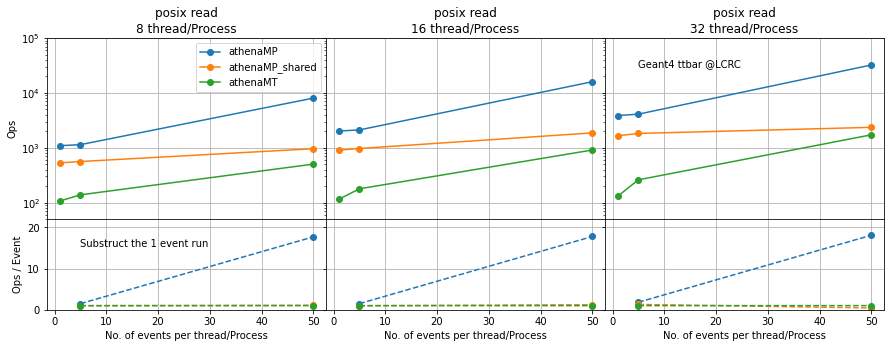

In [160]:
def plot_withfork(df,var,op,tit,ylabel,logy,ylim,ylim2):
    if 'time' in var:
        df=df.query("fork!='worker' and fork!='shared_writer' and fork!='evt_counter' and proc>1 and evt!=15 ",engine='python'
                    ).sort_values(['evt','athena','proc']).reset_index(drop=True)
        df[var]=df[var].astype("timedelta64[s]")
    else:
        df=df.query("proc>1 and evt!=15 ",engine='python'
                    ).sort_values(['evt','athena','proc']).reset_index(drop=True)
    df_main=df.groupby(['evt','athena','proc']).agg({var:op})
    if op=='max':
        df_max_idx = df.groupby(['evt','athena','proc'])[var].transform(max) == df[var]
#         print(df[df_max_idx])
    df_main=df_main.reset_index(level=[0,1,2])
#     print(df_main)
    df_main[var+'_sub1']=df_main[var]
    for nevt in list(df_main.evt.unique()):
        if nevt==1: continue
        df_main.loc[df_main.evt==nevt,var+'_sub1']=(df_main.loc[df_main.evt==nevt,var+'_sub1']-df_main.iloc[:len(df_main.loc[df_main.evt==1])][var].values)
        df_main.loc[df_main.evt==nevt,var+'_sub1']=df_main.loc[df_main.evt==nevt,var+'_sub1']/(df_main.loc[df_main.evt==nevt,'evt']-1)/df_main.loc[df_main.evt==nevt,'proc']

    fig1,ax = plt.subplots(2,3,figsize=(15, 5),gridspec_kw={
                           'height_ratios':[2, 1],'wspace':0,'hspace':0}
                           ,sharex=True,sharey=False)
#     fig2,ax2 = plt.subplots(1,3,figsize=(15, 3),sharex=True,sharey=True)
    xlabel='No. of events per thread/Process'
    df_main.set_index(['evt'],inplace=True)
    for i,p in enumerate([8,16,32]):
        title=tit+'\n'+str(p)+' thread/Process'
        df_main.loc[df_main.proc==p].groupby(['athena'])[var].plot(xlabel=xlabel,ylabel=ylabel,marker='o',ax=ax[0][i]
                                                                   ,title=title,logy=logy,legend=False,grid=True
                                                                  ,ylim=ylim)
        df_main.loc[(df_main.proc==p) & (df_main.index!=1)].groupby(['athena'])[var+'_sub1'].plot(stacked=False,marker='o',linestyle='dashed'
                                                                    ,xlabel=xlabel,ylabel=ylabel+' / Event',ax=ax[1][i]
                                                                    ,ylim=ylim2,logy=False,grid=True)
    if logy:
        ax[0][2].text(5,ax[0][0].get_ylim()[1]*0.3,'Geant4 ttbar @LCRC')
        ax[1][0].text(5,ax[1][0].get_ylim()[1]*0.7,'Substruct the 1 event run')
    else:
        ax[0][2].text(5,ax[0][0].get_ylim()[1]*0.75,'Geant4 ttbar @LCRC')
        ax[1][0].text(5,ax[1][0].get_ylim()[0]*2,'Substruct the 1 event run')
    ax[0][0].legend()
    for i in [0,1]:
        for j in [1,2]:
            ax[i][j].tick_params('y', labelleft=False)
            ax[i][j].set_ylabel('')
#     fig1.subplots_adjust(0,0,1,1,0,0)
#     fig2.subplots_adjust(0,0,1,1,0,0)

# plt.tight_layout()
# df_main
plot_withfork(df_ttbar,'posix read','sum','posix read','Ops',True,[50,100000],[0,22])
# plot_withfork(df_ttbar,'posix write','sum','posix write','Ops',True,[50,100000],[10,27])
# plot_withfork(df_ttbar,'posix bytes read','sum','posix read','MB',True,[0.2,5000],[0.005,12])
# plot_withfork(df_ttbar,'posix bytes written','sum','posix write','MB',True,[0.2,5000],[0.2,10])
# plot_withfork(df_ttbar,'time','sum','running time','Sec',False,[0,23000],[3,22])
# for ops in [x for x in df_ttbar.columns if 'posix' in x]:
#     op='max' if 'max' in ops else 'sum' 
#     plot_withfork(df_ttbar,ops,op,ops,'Ops',False)
# plot_withfork(df_ttbar,'posix_read','posix read','Ops (Total, All Processes)')
# plot_withfork(df_ttbar,'posix_write','posix write','Ops (Total, All Processes)')


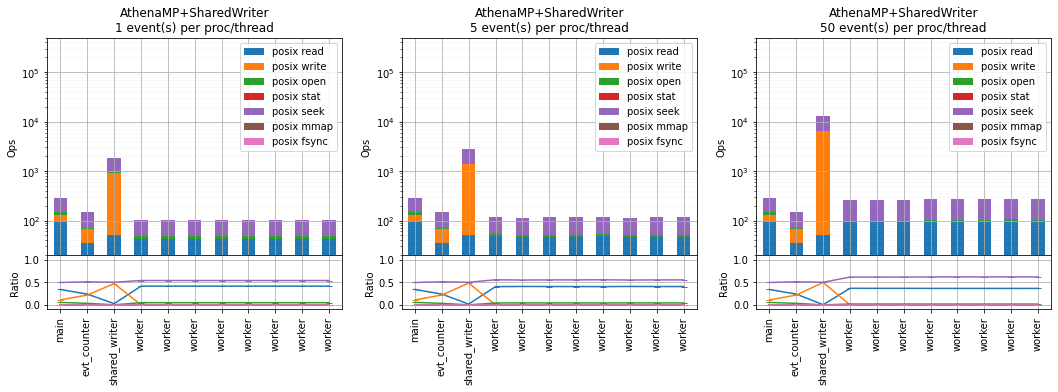

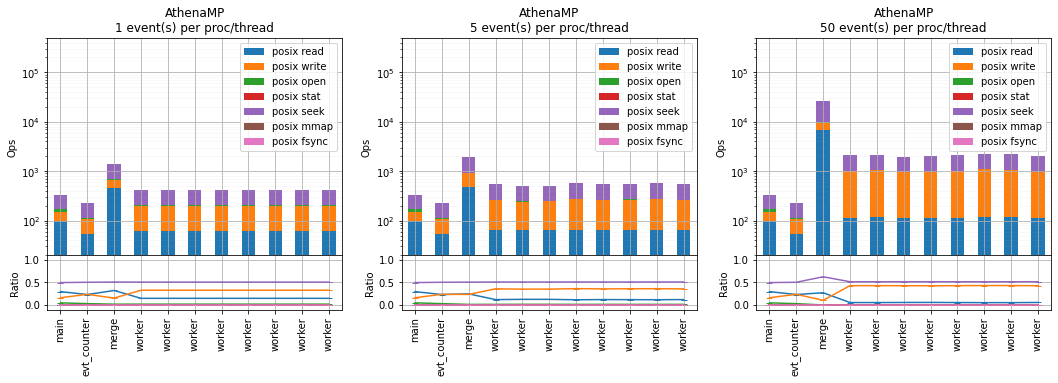

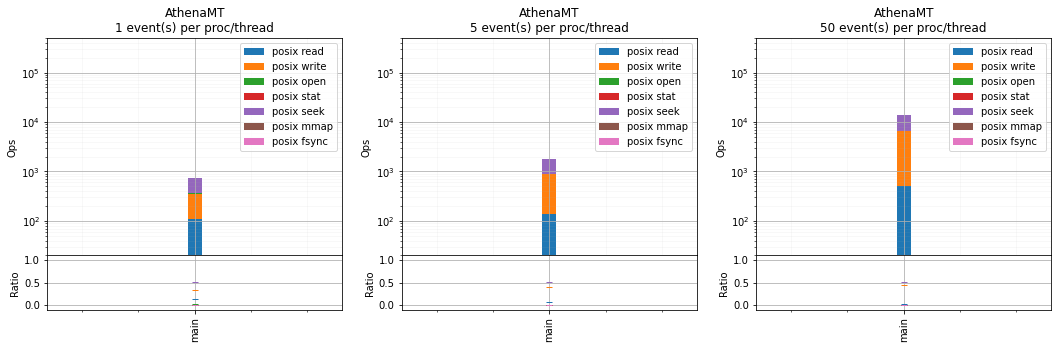

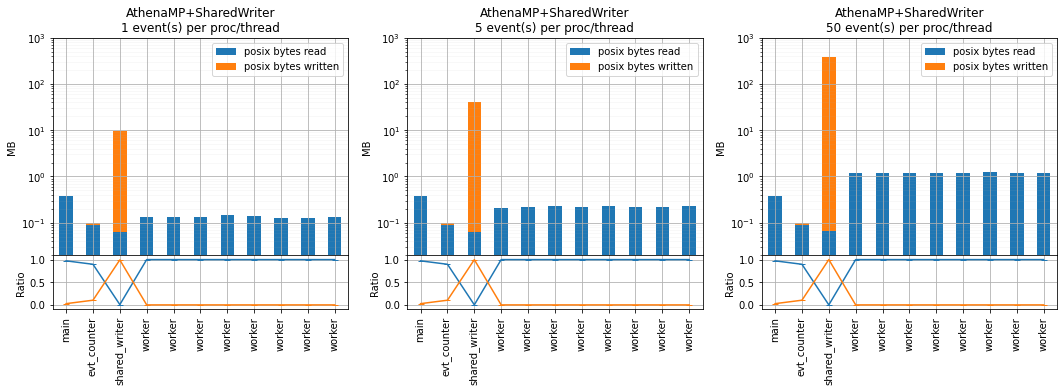

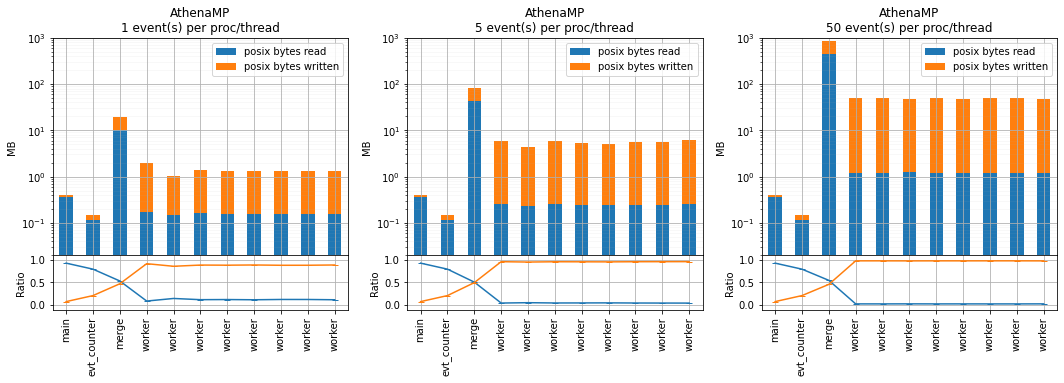

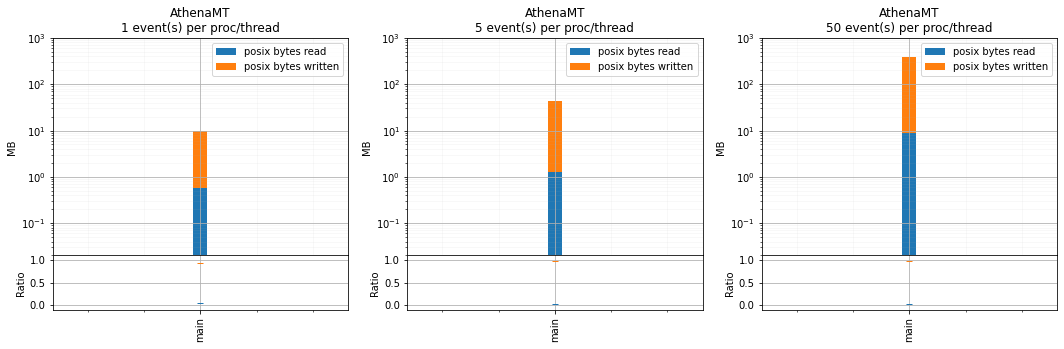

In [113]:
def plot_main_fork(df,var,xlabel,ylabel,title,logy,ylim,width=0.5):
    df.set_index(['fork'],inplace=True)
    fig,ax = plt.subplots(2,3,figsize=(18, 5),gridspec_kw={'height_ratios':[4, 1],'wspace':0.2,'hspace':0}
                           ,sharex=True,sharey=False)
    for i,e in enumerate([1,5,50]):
        tmpdf=df[df.evt==e].sort_index().reset_index()
        if len(tmpdf)>1: tmpdf=tmpdf.reindex([1,0]+list(tmpdf.index)[2:])
        rvar=[]
        for v in var:
            rvar.append(v+' ratio')
            tmpdf[v+' ratio']=tmpdf[v]/tmpdf[var].sum(axis=1)
#         print(tmpdf)
        tmpdf.loc[:,['fork']+var].plot.bar('fork',xlabel=xlabel,ylabel=ylabel,ax=ax[0][i],logy=logy,grid=True
                                                       ,title=title+str(e)+' event(s) per proc/thread'
                                                       ,legend=True,stacked=True,ylim=ylim,width=width)
        tmpdf.loc[:,['fork']+rvar].plot('fork',xlabel=xlabel,ylabel='Ratio',ax=ax[1][i],logy=False,grid=True
                                                       ,legend=False,ylim=[-0.1,1.1],rot=90,marker='_')
        ax[1][i].set_yticks([0,0.5,1])
        ax[0][i].grid(which='minor', alpha=0.1)

#     ax[2].legend()
    
#     print(df)
#     df[df.evt==1].groupby(['athena'])[var].plot.bar(xlabel=xlabel,ylabel=ylabel,title=title,ax=ax)
mods=['athenaMP_shared','athenaMP','athenaMT']
titles=['AthenaMP+SharedWriter\n','AthenaMP\n','AthenaMT\n']
width=[0.5,0.5,0.025]

var=['posix read','posix write','posix open','posix stat','posix seek','posix mmap','posix fsync']
ylim=[20,500000]
for i,mod in enumerate(mods):
    plot_main_fork(df_ttbar[(df_ttbar.athena==mod) & (df_ttbar.proc==8)],var,'','Ops',titles[i],True,ylim,width[i])

ylim=[0.02,1000]
var=['posix bytes read','posix bytes written']#,'posix max bytes read','posix max bytes written']
for i,mod in enumerate(mods):
    plot_main_fork(df_ttbar[(df_ttbar.athena==mod) & (df_ttbar.proc==8)],var,'','MB',titles[i],True,ylim,width[i])

In [42]:
# reports_ttbar[0].records['POSIX']['fcounters']#.to_numpy()
for r in freports_ttbar[:1]:
    create_timeline(r)
    print(r.filename.split('/')[3].split('_')[0:5])
    print(r.summary['timeline'])
#     for it in r.summary['timeline']['items']:
#         print(it['id'],it['name'],it['end'])

['OPEN', 'CLOSE', 'READ', 'WRITE']
POSIX:12404580837862791563:OPEN
POSIX:12404580837862791563:CLOSE
POSIX:12404580837862791563:READ
POSIX:12404580837862791563:WRITE
['OPEN', 'CLOSE', 'READ', 'WRITE']
POSIX:8931218811399706635:OPEN
POSIX:8931218811399706635:CLOSE
POSIX:8931218811399706635:READ
POSIX:8931218811399706635:WRITE
['athenaMT', 'FullG4', 'ttbar', '8', '1']
{'groups': [{'id': 'POSIX', 'content': 'POSIX', 'order': 5.0, 'nestedGroups': ['POSIX:12404580837862791563', 'POSIX:8931218811399706635'], 'showNested': False}, {'id': 'STDIO', 'content': 'STDIO', 'order': 4.0}, {'id': 'DXT_POSIX', 'content': 'DXT_POSIX', 'order': 6.0}, {'id': 'HEATMAP', 'content': 'HEATMAP', 'order': 8.0}, {'id': 'POSIX:12404580837862791563', 'content': '<b>/cvmfs/atlas-nightl..._000012.pool.root.1</b><br>POSIX:12404580837862791563', 'order': 0.0, 'title': '/cvmfs/atlas-nightlies.cern.ch/repo/data/data-art/SimCoreTests/valid1.410000.PowhegPythiaEvtGen_P2012_ttbar_hdamp172p5_nonallhad.evgen.EVNT.e4993.EVNT.0

In [55]:
r.records['POSIX'].to_df()['counters'].keys()

Index(['rank', 'id', 'POSIX_OPENS', 'POSIX_FILENOS', 'POSIX_DUPS',
       'POSIX_READS', 'POSIX_WRITES', 'POSIX_SEEKS', 'POSIX_STATS',
       'POSIX_MMAPS', 'POSIX_FSYNCS', 'POSIX_FDSYNCS', 'POSIX_RENAME_SOURCES',
       'POSIX_RENAME_TARGETS', 'POSIX_RENAMED_FROM', 'POSIX_MODE',
       'POSIX_BYTES_READ', 'POSIX_BYTES_WRITTEN', 'POSIX_MAX_BYTE_READ',
       'POSIX_MAX_BYTE_WRITTEN', 'POSIX_CONSEC_READS', 'POSIX_CONSEC_WRITES',
       'POSIX_SEQ_READS', 'POSIX_SEQ_WRITES', 'POSIX_RW_SWITCHES',
       'POSIX_MEM_NOT_ALIGNED', 'POSIX_MEM_ALIGNMENT',
       'POSIX_FILE_NOT_ALIGNED', 'POSIX_FILE_ALIGNMENT',
       'POSIX_MAX_READ_TIME_SIZE', 'POSIX_MAX_WRITE_TIME_SIZE',
       'POSIX_SIZE_READ_0_100', 'POSIX_SIZE_READ_100_1K',
       'POSIX_SIZE_READ_1K_10K', 'POSIX_SIZE_READ_10K_100K',
       'POSIX_SIZE_READ_100K_1M', 'POSIX_SIZE_READ_1M_4M',
       'POSIX_SIZE_READ_4M_10M', 'POSIX_SIZE_READ_10M_100M',
       'POSIX_SIZE_READ_100M_1G', 'POSIX_SIZE_READ_1G_PLUS',
       'POSIX_SIZE_WRITE_

In [106]:
r.agg_ioops()
# !for file in $(find workdir/Athena_23_0_5/ -type f -name 'log.EVNTtoHITS'); do echo $file; done
# print(r.__dir__())
# print(r.modules)
# r.records['POSIX'].__hash__()
# nr=r.name_records
# ex_list=['.py','perfmon','PoolFileCatalog','eventLoopHeartBeat','.db','libdarshan.so','atlas-condb'
#          ,'.tmp','STD','POSIX']
# # import fname,re
# names=[]
# for k, v in nr.items():
#     match=False
#     for ex in ex_list:
#         if ex in v:
#             match=True
#             break
#     if not match:
#         names.append(v)
# print(names)
# # print(r.name_records_summary())
# rr=r.filter(name_records=names)
# print(rr.name_records_summary())
# rr.agg_ioops()
# d = {k: v for k, v in nr.items() if for }

{'POSIX': {'POSIX_OPENS': 5,
  'POSIX_FILENOS': 0,
  'POSIX_DUPS': 0,
  'POSIX_READS': 43,
  'POSIX_WRITES': 0,
  'POSIX_SEEKS': 56,
  'POSIX_STATS': 10,
  'POSIX_MMAPS': -1,
  'POSIX_FSYNCS': 0,
  'POSIX_FDSYNCS': 0,
  'POSIX_RENAME_SOURCES': 0,
  'POSIX_RENAME_TARGETS': 0,
  'POSIX_RENAMED_FROM': 0,
  'POSIX_MODE': 0,
  'POSIX_BYTES_READ': 149238,
  'POSIX_BYTES_WRITTEN': 0,
  'POSIX_MAX_BYTE_READ': 113638962,
  'POSIX_MAX_BYTE_WRITTEN': 0,
  'POSIX_CONSEC_READS': 1,
  'POSIX_CONSEC_WRITES': 0,
  'POSIX_SEQ_READS': 23,
  'POSIX_SEQ_WRITES': 0,
  'POSIX_RW_SWITCHES': 0,
  'POSIX_MEM_NOT_ALIGNED': 0,
  'POSIX_MEM_ALIGNMENT': 8,
  'POSIX_FILE_NOT_ALIGNED': 38,
  'POSIX_FILE_ALIGNMENT': 512,
  'POSIX_MAX_READ_TIME_SIZE': 43293,
  'POSIX_MAX_WRITE_TIME_SIZE': 0,
  'POSIX_SIZE_READ_0_100': 0,
  'POSIX_SIZE_READ_100_1K': 31,
  'POSIX_SIZE_READ_1K_10K': 10,
  'POSIX_SIZE_READ_10K_100K': 2,
  'POSIX_SIZE_READ_100K_1M': 0,
  'POSIX_SIZE_READ_1M_4M': 0,
  'POSIX_SIZE_READ_4M_10M': 0,
  'POSIX_S

In [ ]:
def plot_withfork(df,var,tit,ylabel):
    if 'time' in var:
        df_main=df.query("fork!=1 and proc>1 and evt!=15 ",engine='python'
                    ).sort_values(['evt','athena','proc']).reset_index(drop=True)
        df_main[var]=df_main[var].astype("timedelta64[s]")
#         df_main[var+'_sub1']=df_main[var+'_sub1'].astype("timedelta64[s]")
    else:
        df_main=df.query("proc>1 and evt!=15 ",engine='python'
                    ).sort_values(['evt','athena','proc']).reset_index(drop=True)
    df_main=df_main.groupby(['evt','athena','proc']).sum().reset_index(level=[0,1,2])
    for iv,v in enumerate(var):
        df_main[v+'_sub1']=df_main[v]
        for nevt in list(df_main.evt.unique()):
            if nevt==1: continue
            df_main.loc[df_main.evt==nevt,v+'_sub1']=(df_main.loc[df_main.evt==nevt,v+'_sub1']-df_main.iloc[:len(df_main.loc[df_main.evt==1])][v].values)
            df_main.loc[df_main.evt==nevt,v+'_sub1']=df_main.loc[df_main.evt==nevt,v+'_sub1']/(df_main.loc[df_main.evt==nevt,'evt']-1)/df_main.loc[df_main.evt==nevt,'proc']

    fig1,ax1 = plt.subplots(1,3,figsize=(15, 4),sharex=True,sharey=True)
    fig2,ax2 = plt.subplots(1,3,figsize=(15, 4),sharex=True,sharey=True)
    xlabel='No. of events per thread/Process'
    df_main.set_index(['evt'],inplace=True)
#     print(df_main)
    for i,p in enumerate(list(df_main.proc.unique())):
        title='total '+tit+', LCRC, '+str(p)+' thread/Process'
#         df_main.loc[df_main.proc==p].groupby(['athena'])[var].plot.bar(ax=ax1[i],label='a')
        for im,mod in enumerate(list(df_main.athena.unique())):
            width=1./len(list(df_main.athena.unique()))/8
            pos=8*width*im
            print(width,pos)
            tdf=df_main.loc[(df_main.proc==p) & (df_main.athena==mod)]
            tdf[var].plot(kind='bar',ax=ax1[i],position=pos,width=width,stacked=True)
# #         df_main.loc[df_main.proc==p].groupby(['athena'])[v].plot(xlabel=xlabel,ylabel=ylabel,marker='o',ax=ax1[i]
# #                                                                    ,title=title,logy=False,legend=True,grid=True)
#         title='per event '+tit+', LCRC, '+str(p)+' thread/Process\n(by substructing the 1 event run)'
#         pos=1./len(var)*(iv+1)
#         df_main.loc[df_main.proc==p].groupby(['athena'])[v+'_sub1'].plot(logy=True,stacked=False,kind='bar' #,marker='o'
#                                                                         ,xlabel=xlabel,ylabel=ylabel+' / event',ax=ax2[i]
# #                                                                         ,ylim=[0.1,100000]
#                                                                          ,position=pos
#                                                                            ,title=title,legend=True,grid=True)
    plt.legend()
    fig1.subplots_adjust(0,0,1,1,0,0)
    fig2.subplots_adjust(0,0,1,1,0,0)

# plt.tight_layout()
# df_main
plot_withfork(df_ttbar,['posix_read','posix_write'],'posix','Ops (Total, All Processes)')


In [ ]:
def plot(df,var,tit,ylabel):
    df_main=df.query("fork==False and proc>1 and evt!=15 ",engine='python'
                    ).sort_values(['evt','athena','proc']).reset_index(drop=True)
    df_main[var+'_sub1']=df_main[var]
    df_main.loc[df_main.evt==1,var+'_sub1']=df_main.loc[df_main.evt==1,var+'_sub1']/df_main.loc[df_main.evt==1,'evt']/df_main.loc[df_main.evt==1,'proc']
    df_main.loc[df_main.evt==5,var+'_sub1']=(df_main.loc[df_main.evt==5,var+'_sub1']-df_main.iloc[:len(df_main.loc[df_main.evt==5])][var].values)
    df_main.loc[df_main.evt==5,var+'_sub1']=df_main.loc[df_main.evt==5,var+'_sub1']/df_main.loc[df_main.evt==5,'evt']/df_main.loc[df_main.evt==5,'proc']
    df_main.loc[df_main.evt==50,var+'_sub1']=df_main.loc[df_main.evt==50,var+'_sub1']-df_main.iloc[:len(df_main.loc[df_main.evt==50])][var].values
    df_main.loc[df_main.evt==50,var+'_sub1']=df_main.loc[df_main.evt==50,var+'_sub1']/df_main.loc[df_main.evt==50,'evt']/df_main.loc[df_main.evt==50,'proc']
    if 'time' in var:
        df_main[var]=df_main[var].astype("timedelta64[s]")
        df_main[var+'_sub1']=df_main[var+'_sub1'].astype("timedelta64[s]")

    fig,ax1 = plt.subplots(1,3,figsize=(15, 4),sharex=True,sharey=True, constrained_layout=True)
    fig,ax2 = plt.subplots(1,3,figsize=(18, 4),sharex=True,sharey=True, constrained_layout=True)
    xlabel='No. of events per thread/Process'
    df_main.set_index(['evt'],inplace=True)
    for i,p in enumerate([8,16,32]):
        title='total '+tit+', LCRC, '+str(p)+' thread/Process'
        df_main.loc[df_main.proc==p].groupby(['athena'])[var].plot(xlabel=xlabel,ylabel=ylabel,marker='o',ax=ax1[i]
                                                                   ,title=title,logy=False,legend=True,grid=True)
        title='per event '+tit+', LCRC, '+str(p)+' thread/Process\n(by substructing the 1 event run)'
        df_main.loc[df_main.proc==p].groupby(['athena'])[var+'_sub1'].plot(logy=False,marker='o'
                                                                        ,xlabel=xlabel,ylabel=ylabel+' / event',ax=ax2[i]
#                                                                         ,ylim=[0.1,100000]
                                                                           ,title=title,legend=True,grid=True)
    plt.legend()

# plt.tight_layout()
# df_main
plot(df_ttbar,'time','running time','Sec')
plot(df_ttbar[df_ttbar.athena!='athenaMT'],'posix_read','posix read','Ops (Total, All Processes)')
plot(df_ttbar[df_ttbar.athena!='athenaMT'],'posix_write','posix write','Ops (Total, All Processes)')


In [ ]:
from darshan.experimental.aggregators import create_time_summary
reports_athenaMP[0].start_time

In [ ]:
reports[1].data
# reports_athena[0].summarize()

In [ ]:
print('fork_parent' in reports[1].metadata['job']['metadata'].keys())

In [ ]:
# reports_ttbar=[r for r in reports_ttbar if 'TempAthenaConfig' not in r.metadata['exe'] ]
# rs = [r for r in reports_ttbar if 'TempAthenaConfig' in r.metadata['exe'] ]
# rs[0].info()

In [ ]:
from darshan.experimental.plots import plot_dxt_heatmap2
plot_dxt_heatmap2(reports[0],mods=['DXT_POSIX'])

In [ ]:
from darshan.experimental.plots import plot_access_histogram
file='workdir/Athena_23_0_5/athenaMP_FullG4_ttbar_32_50_False/rwang_python_id170690-170690_9-3-810-9782348938453296783_1.darshan'
report=darshan.DarshanReport(file, read_all=True, dtype='numpy')
plot_access_histogram(report,'POSIX')

In [ ]:
file='workdir/Athena_23_0_5/athenaMP_FullG4_ttbar_32_50_False/rwang_python_id171872-171872_9-3-1048-14829239743032846552_1.darshan'
report=darshan.DarshanReport(file, read_all=True, dtype='numpy')
plot_access_histogram(report,'POSIX')

In [ ]:
file='workdir/Athena_23_0_5/athenaMP_FullG4_ttbar_32_50_False/rwang_python_id171872-172211_9-3-1248-6990502124633823591_1.darshan'
report=darshan.DarshanReport(file, read_all=True, dtype='numpy')
plot_access_histogram(report,'POSIX')

In [ ]:
from darshan.experimental.plots import plot_opcounts
# for r in reports:
#     plt = plot_opcounts(r,'POSIX')
#     plt.show()
plot_opcounts(reports[0],'POSIX')

In [ ]:
file="workdir/Athena_23_0_5/athena_FullG4_ttbar_8_15/rwang_python_id181758-181758_8-23-63299-13156225266158396904_1.darshan"
report = darshan.DarshanReport(file, read_all=True)  # Default behavior
report.info()

In [ ]:
report.records['DXT_POSIX'][0]._records[0].keys()

In [ ]:
plot_dxt_heatmap.plot_heatmap(report)
plt.plot()